# Fine-tune `VietAI/vit5-large` bằng LoRA cho bài toán tóm tắt tiếng Việt ở cấu hình cân bằng cho A100 40GB

Notebook này được cấu hình để chạy ổn định trên GPU **A100 40GB** cho fine-tune ViT5-large:

- Dùng **BF16** và **TF32** để tận dụng Tensor Core trên A100.
- Giảm độ dài token và batch size so với bản A100 80GB để hạn chế OOM.
- Dùng LoRA rank vừa phải, vẫn gắn vào attention + feed-forward để giữ năng lực học tốt.
- Giữ `auto_find_batch_size=True` để Trainer tự hạ batch nếu môi trường thực tế thiếu VRAM.
- Có callback vẽ **training loss/eval loss live trong lúc huấn luyện**, đồng thời lưu biểu đồ PNG và lịch sử loss CSV.
- Có đầy đủ metric: ROUGE, BLEU, BERTScore, Too Short Rate và length ratio.

Nếu vẫn bị OOM, giảm `PER_DEVICE_TRAIN_BATCH_SIZE` từ 8 xuống 4 hoặc bật `GRADIENT_CHECKPOINTING=True`.


## Cell 1 — Cài thư viện

**Nhiệm vụ:** Cài các thư viện cần cho toàn bộ notebook.

**Ý nghĩa:** Cell này chỉ chạy một lần ở đầu Colab. Sau khi cài xong, các cell sau mới import được `transformers`, `peft`, `datasets`, `evaluate`, tokenizer ViT5 và các metric.

In [ ]:
%%capture
# NHIỆM VỤ:
# - Cài thư viện cho fine-tune ViT5-large bằng LoRA.
# - %%capture giúp ẩn log pip dài để notebook gọn hơn.

!pip install \
    transformers==4.39.3 \
    peft==0.10.0 \
    accelerate==0.27.2 \
    datasets \
    evaluate \
    rouge-score \
    sacrebleu \
    sentencepiece \
    pyarrow \
    nltk \
    bert-score

# Ý nghĩa từng package:
# transformers==4.39.3:
#   Dùng để load tokenizer, model ViT5, Seq2SeqTrainer và TrainingArguments.
# peft==0.10.0:
#   Dùng để fine-tune bằng LoRA, chỉ train một phần nhỏ tham số.
# accelerate==0.27.2:
#   Hỗ trợ Trainer chạy GPU, FP16 và phân phối thiết bị ổn định hơn.
# datasets:
#   Chuyển pandas DataFrame sang Hugging Face Dataset và map tokenizer.
# evaluate:
#   Load metric như ROUGE và SacreBLEU.
# rouge-score:
#   Backend cần thiết để evaluate tính ROUGE.
# sacrebleu:
#   Backend cần thiết để evaluate tính BLEU.
# sentencepiece:
#   Tokenizer gốc của các model T5/ViT5.
# pyarrow:
#   Đọc file .parquet.
# nltk:
#   Thư viện NLP phụ trợ, một số metric/pipeline có thể cần.
# bert-score:
#   Metric đánh giá tương đồng ngữ nghĩa, để tùy chọn vì chạy chậm hơn ROUGE/BLEU.

## Cell 2 — Import thư viện và khai báo cấu hình toàn cục cho A100 40GB

**Nhiệm vụ:** Gom toàn bộ cấu hình chính vào một nơi: đường dẫn dữ liệu, chế độ debug/full train, độ dài token, tham số train, tham số LoRA, tham số generate và cấu hình vẽ loss.

**Ý nghĩa:** Các cell sau chỉ đọc biến từ đây, nên khi muốn đổi mức sử dụng VRAM/tốc độ/chất lượng thì chỉ cần chỉnh cell này. Bản này là cấu hình cân bằng cho A100 40GB, an toàn hơn bản A100 80GB.


In [ ]:
# NHIỆM VỤ:
# - Import thư viện.
# - Khai báo toàn bộ cấu hình chính của pipeline.
# - Tạo các thư mục output cần thiết.
# - Tối ưu cấu hình train cân bằng cho GPU A100 40GB.
# - Khai báo cấu hình lưu/vẽ loss trong quá trình huấn luyện.

import os                 # Làm việc với đường dẫn, biến môi trường và tạo thư mục.
import json               # Lưu metric ra file .json.
import inspect            # Kiểm tra tham số của TrainingArguments để tương thích nhiều version.
from pathlib import Path  # Xử lý đường dẫn kiểu object, tiện khi nén output.

import numpy as np        # Xử lý mảng, thay label -100 khi decode metric.
import pandas as pd       # Đọc/làm sạch dữ liệu .parquet và lưu loss history.
import torch              # Framework deep learning chính.
import evaluate           # Load metric ROUGE/BLEU.
import matplotlib.pyplot as plt  # Vẽ biểu đồ loss.

from datasets import Dataset  # Chuyển DataFrame sang Hugging Face Dataset.
from IPython.display import clear_output, display  # Cập nhật biểu đồ loss live trong notebook.

from transformers import (
    AutoTokenizer,              # Load tokenizer tương ứng với MODEL_NAME.
    AutoModelForSeq2SeqLM,      # Load model encoder-decoder cho bài toán seq2seq.
    DataCollatorForSeq2Seq,     # Padding động cho batch seq2seq.
    Seq2SeqTrainer,             # Trainer chuyên cho bài toán sinh chuỗi.
    Seq2SeqTrainingArguments,   # Chứa toàn bộ tham số train/eval/save/log.
    TrainerCallback,            # Callback để vẽ loss trong quá trình huấn luyện.
    set_seed,                   # Cố định seed để kết quả dễ tái lập hơn.
)

from peft import (
    LoraConfig,       # Cấu hình LoRA.
    get_peft_model,   # Gắn LoRA vào base model.
    TaskType,         # Khai báo loại task cho PEFT.
)

# Tắt Weights & Biases để Colab không hỏi đăng nhập.
os.environ["WANDB_DISABLED"] = "true"

# Tắt tokenizer parallelism để giảm warning và tránh treo tiến trình khi map dữ liệu.
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Cố định seed.
set_seed(42)

# =========================
# 1. Cấu hình model
# =========================

MODEL_NAME = "VietAI/vit5-large"
TASK_PREFIX = "vietnamese summary: "

# =========================
# 2. Cấu hình đường dẫn Colab
# =========================

PROJECT_DIR = "/content/NLP"
DATA_DIR = f"{PROJECT_DIR}/data"
OUTPUT_BASE_DIR = f"{PROJECT_DIR}/output"
OUTPUT_DIR = f"{OUTPUT_BASE_DIR}/vit5-large-lora-a100-40gb-balanced"

TRAIN_PATH = f"{DATA_DIR}/train.parquet"
VALID_PATH = f"{DATA_DIR}/val.parquet"

PREDICTION_CSV = f"{OUTPUT_BASE_DIR}/vit5_large_a100_40gb_validation_predictions.csv"
METRICS_JSON = f"{OUTPUT_BASE_DIR}/vit5_large_a100_40gb_validation_metrics.json"
BERTSCORE_JSON = f"{OUTPUT_BASE_DIR}/vit5_large_a100_40gb_validation_bertscore.json"
EXAMPLES_CSV = f"{OUTPUT_BASE_DIR}/vit5_large_a100_40gb_examples_for_report.csv"
LOSS_PLOT_PNG = f"{OUTPUT_BASE_DIR}/vit5_large_a100_40gb_loss_curve.png"
LOSS_HISTORY_CSV = f"{OUTPUT_BASE_DIR}/vit5_large_a100_40gb_loss_history.csv"
LOSS_EPOCH_PLOT_PNG = f"{OUTPUT_BASE_DIR}/vit5_large_a100_40gb_epoch_loss_curve.png"
LOSS_EPOCH_HISTORY_CSV = f"{OUTPUT_BASE_DIR}/vit5_large_a100_40gb_epoch_loss_history.csv"
ZIP_PATH = f"{OUTPUT_BASE_DIR}/vit5_large_a100_40gb_outputs.zip"

os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUTPUT_BASE_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# =========================
# 3. Cấu hình cột dữ liệu
# =========================

SOURCE_COL = "article"
TARGET_COL = "summary"

# =========================
# 4. Chế độ debug/full train
# =========================

DEBUG_MODE = False
DEBUG_TRAIN_SIZE = 500
DEBUG_VALID_SIZE = 100

# =========================
# 5. Cấu hình tokenize cho A100 40GB
# =========================

# 768 token là mức cân bằng cho A100 40GB: giảm VRAM so với 1024 nhưng vẫn giữ nhiều ngữ cảnh hơn 512.
MAX_SOURCE_LENGTH = 768

# 192 token đủ rộng cho đa số summary, nhẹ hơn mức 256 của bản A100 80GB.
MAX_TARGET_LENGTH = 192

# Tăng song song khi tokenize; nếu Colab/VM ít CPU hoặc lỗi multiprocessing thì giảm về 2-4.
TOKENIZE_NUM_PROC = 4

# =========================
# 6. Cấu hình train cân bằng cho A100 40GB
# =========================

NUM_TRAIN_EPOCHS = 6
LEARNING_RATE = 1e-4
LR_SCHEDULER_TYPE = "cosine"
WARMUP_RATIO = 0.06
WEIGHT_DECAY = 0.01
MAX_GRAD_NORM = 1.0
LABEL_SMOOTHING_FACTOR = 0.05

# Batch 8 với seq 768/192 phù hợp A100 40GB.
# Effective batch size = 8 * 2 = 16: ổn định hơn batch nhỏ, nhưng nhẹ hơn cấu hình 80GB.
PER_DEVICE_TRAIN_BATCH_SIZE = 8
PER_DEVICE_EVAL_BATCH_SIZE = 8
GRADIENT_ACCUMULATION_STEPS = 2

BF16 = True
FP16 = False
ENABLE_TF32 = True

# Mặc định tắt để ưu tiên tốc độ trên A100 40GB. Nếu OOM, bật True để giảm VRAM.
GRADIENT_CHECKPOINTING = False
AUTO_FIND_BATCH_SIZE = True
OPTIMIZER = "adamw_torch_fused"

DATALOADER_NUM_WORKERS = 4
DATALOADER_PIN_MEMORY = True
DATALOADER_PERSISTENT_WORKERS = True
GROUP_BY_LENGTH = True
EVAL_ACCUMULATION_STEPS = 2

# Không generate trong Trainer evaluation để training nhanh hơn; eval_loss vẫn được log mỗi epoch.
PREDICT_WITH_GENERATE_DURING_TRAINING = False
GENERATION_NUM_BEAMS_DURING_TRAINING = 1

# Log dày hơn để biểu đồ loss có đủ điểm trong lúc train.
LOGGING_STEPS = 10
SAVE_TOTAL_LIMIT = 3

# =========================
# 7. Cấu hình LoRA cân bằng cho A100 40GB
# =========================

# Rank 32 cân bằng giữa chất lượng và VRAM cho A100 40GB; nhẹ hơn rank 64 của bản 80GB.
LORA_R = 32
LORA_ALPHA = 64
LORA_DROPOUT = 0.05

# Gắn LoRA vào attention và feed-forward của T5/ViT5 để tăng năng lực thích nghi.
# Danh sách này bao phủ cả biến thể có wi và biến thể gated có wi_0/wi_1.
LORA_TARGET_MODULES = ["q", "k", "v", "o", "wi", "wi_0", "wi_1", "wo"]
LORA_USE_RSLORA = True

# =========================
# 8. Cấu hình vẽ loss
# =========================

LIVE_LOSS_PLOT = True
LOSS_PLOT_UPDATE_EVERY_LOG = 1

# =========================
# 9. Cấu hình generate cuối cùng
# =========================

FINAL_GENERATE_BATCH_SIZE = 16
FINAL_NUM_BEAMS = 4
FINAL_MIN_LENGTH = 30
FINAL_NO_REPEAT_NGRAM_SIZE = 3
VALIDATION_MAX_GENERATE_SAMPLES = None

# Bật True để tính BERTScore trong cell metric cuối cùng.
# BERTScore chạy chậm hơn ROUGE/BLEU vì phải load mô hình embedding.
RUN_BERTSCORE = True

# Model embedding dùng cho BERTScore.
# Dùng multilingual BERT để hỗ trợ tiếng Việt ổn định trên Colab.
BERTSCORE_MODEL_TYPE = "bert-base-multilingual-cased"

# Batch size khi tính BERTScore. Nếu OOM ở bước metric thì giảm về 4.
METRIC_BATCH_SIZE = 8

# TOO_SHORT_MIN_TOKENS:
#   Nếu prediction có ít hơn số token này thì coi là quá ngắn.
#   Ngưỡng 5 giúp bắt các output rỗng, rất ngắn hoặc gần như không có nội dung.
TOO_SHORT_MIN_TOKENS = 5

# TOO_SHORT_REF_RATIO:
#   Nếu prediction ngắn hơn 50% độ dài reference thì coi là quá ngắn.
#   Metric này bổ sung cho ROUGE/BLEU để phát hiện model sinh summary quá cụt.
TOO_SHORT_REF_RATIO = 0.5

# Kiểm tra không bật cả BF16 và FP16 cùng lúc.
if BF16 and FP16:
    raise ValueError("Chỉ được bật một trong hai: BF16 hoặc FP16.")

# =========================
# 10. Tối ưu backend GPU và kiểm tra môi trường
# =========================

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    total_mem_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print("GPU:", gpu_name)
    print("GPU total memory: %.2f GB" % total_mem_gb)
    print("CUDA capability:", torch.cuda.get_device_capability(0))

    if ENABLE_TF32:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        try:
            torch.set_float32_matmul_precision("high")
        except Exception as exc:
            print("Could not set float32 matmul precision:", exc)
        print("TF32 enabled:", torch.backends.cuda.matmul.allow_tf32)

    if BF16 and not torch.cuda.is_bf16_supported():
        raise RuntimeError("BF16 đang bật nhưng GPU hiện tại không hỗ trợ BF16. Hãy đặt BF16=False, FP16=True.")

    if total_mem_gb < 35:
        print("CẢNH BÁO: Cấu hình này nhắm tới A100 40GB. GPU hiện tại dưới 35GB, Trainer có thể phải tự giảm batch size.")
else:
    print("Notebook này được tối ưu cho A100 40GB. Nếu chạy CPU sẽ rất chậm.")

print("Project directory:", PROJECT_DIR)
print("Data directory:", DATA_DIR)
print("Train path:", TRAIN_PATH)
print("Validation path:", VALID_PATH)
print("Output directory:", OUTPUT_DIR)
print("Precision config -> BF16:", BF16, "| FP16:", FP16, "| TF32:", ENABLE_TF32)
print("Token length config -> source:", MAX_SOURCE_LENGTH, "| target:", MAX_TARGET_LENGTH)
print("Train batch config -> per_device:", PER_DEVICE_TRAIN_BATCH_SIZE, "| grad_accum:", GRADIENT_ACCUMULATION_STEPS, "| effective:", PER_DEVICE_TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS)
print("LoRA config -> r:", LORA_R, "| alpha:", LORA_ALPHA, "| targets:", LORA_TARGET_MODULES)
print("Loss plot path:", LOSS_PLOT_PNG)
print("Epoch loss plot path:", LOSS_EPOCH_PLOT_PNG)
print("Metric config -> BERTScore:", RUN_BERTSCORE, "| model:", BERTSCORE_MODEL_TYPE, "| too_short_min_tokens:", TOO_SHORT_MIN_TOKENS, "| too_short_ref_ratio:", TOO_SHORT_REF_RATIO)


CUDA available: True
GPU: NVIDIA A100-SXM4-40GB
GPU total memory: 39.49 GB
CUDA capability: (8, 0)
TF32 enabled: True
Project directory: /content/NLP
Data directory: /content/NLP/data
Train path: /content/NLP/data/train.parquet
Validation path: /content/NLP/data/val.parquet
Output directory: /content/NLP/output/vit5-large-lora-a100-40gb-balanced
Precision config -> BF16: True | FP16: False | TF32: True
Token length config -> source: 768 | target: 192
Train batch config -> per_device: 8 | grad_accum: 2 | effective: 16
LoRA config -> r: 32 | alpha: 64 | targets: ['q', 'k', 'v', 'o', 'wi', 'wi_0', 'wi_1', 'wo']
Loss plot path: /content/NLP/output/vit5_large_a100_40gb_loss_curve.png
Epoch loss plot path: /content/NLP/output/vit5_large_a100_40gb_epoch_loss_curve.png
Metric config -> BERTScore: True | model: bert-base-multilingual-cased | too_short_min_tokens: 5 | too_short_ref_ratio: 0.5


## Cell 3 — Kiểm tra file dữ liệu

**Nhiệm vụ:** Kiểm tra `train.parquet` và `val.parquet` có tồn tại đúng đường dẫn không.

**Ý nghĩa:** Dừng sớm nếu sai path, tránh lỗi khó hiểu ở các cell sau.

In [ ]:
# NHIỆM VỤ:
# - Kiểm tra 2 file bắt buộc trước khi đọc dữ liệu.

# Danh sách path bắt buộc.
required_paths = [TRAIN_PATH, VALID_PATH]

# Lọc ra các path chưa tồn tại.
missing_paths = [p for p in required_paths if not os.path.exists(p)]

# Nếu thiếu file, dừng notebook và báo rõ file nào bị thiếu.
if missing_paths:
    raise FileNotFoundError(
        "Thiếu file dữ liệu. Hãy kiểm tra lại cấu trúc thư mục Colab:\n"
        + "\n".join(missing_paths)
    )

print("Đã tìm thấy đầy đủ file dữ liệu:")
for p in required_paths:
    print("-", p)

Đã tìm thấy đầy đủ file dữ liệu:
- /content/NLP/data/train.parquet
- /content/NLP/data/val.parquet


## Cell 4 — Đọc và làm sạch dữ liệu

**Nhiệm vụ:** Đọc `train.parquet` và `val.parquet`, kiểm tra cột bắt buộc, xóa dòng rỗng, chuẩn hóa khoảng trắng.

**Ý nghĩa:** Đảm bảo dữ liệu đầu vào chỉ còn hai cột sạch: `article` và `summary`.

In [ ]:
# NHIỆM VỤ:
# - Đọc dữ liệu parquet.
# - Kiểm tra cột article/summary.
# - Làm sạch text và loại bỏ dòng không hợp lệ.

def clean_text(text):
    """Chuẩn hóa nhẹ văn bản.

    Parameters:
    - text:
        Giá trị đầu vào, có thể là string hoặc kiểu khác.

    Returns:
    - String đã được ép kiểu, xóa khoảng trắng đầu/cuối và gộp nhiều khoảng trắng liên tiếp.
    """

    # str(text): ép mọi giá trị về string.
    # split(): tách theo mọi khoảng trắng, tự loại khoảng trắng thừa.
    # " ".join(...): ghép lại bằng đúng một dấu cách.
    return " ".join(str(text).split())


def load_and_clean_parquet(path, source_col=SOURCE_COL, target_col=TARGET_COL):
    """Đọc và làm sạch một file parquet.

    Parameters:
    - path:
        Đường dẫn file .parquet cần đọc.
    - source_col:
        Tên cột chứa article đầu vào.
    - target_col:
        Tên cột chứa summary chuẩn.

    Returns:
    - DataFrame chỉ gồm source_col và target_col đã được làm sạch.
    """

    # Đọc parquet thành pandas DataFrame.
    df = pd.read_parquet(path)

    # In thông tin ban đầu để kiểm tra nhanh.
    print(f"\nFile: {path}")
    print("Shape gốc:", df.shape)
    print("Columns:", df.columns.tolist())

    # Kiểm tra cột bắt buộc.
    required_cols = [source_col, target_col]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(
                f"Thiếu cột {col!r} trong {path}. "
                f"Các cột hiện có: {df.columns.tolist()}"
            )

    # Chỉ giữ 2 cột cần thiết.
    # dropna(): xóa dòng có NaN ở article hoặc summary.
    # copy(): tạo bản sao để tránh pandas warning.
    df = df[required_cols].dropna().copy()

    # Chuẩn hóa khoảng trắng.
    df[source_col] = df[source_col].map(clean_text)
    df[target_col] = df[target_col].map(clean_text)

    # Loại dòng rỗng sau khi clean.
    df = df[
        (df[source_col].str.len() > 0)
        & (df[target_col].str.len() > 0)
    ].reset_index(drop=True)

    print("Shape sau làm sạch:", df.shape)
    return df


# Đọc và làm sạch train/validation.
train_df = load_and_clean_parquet(TRAIN_PATH)
valid_df = load_and_clean_parquet(VALID_PATH)

# Hiển thị vài dòng đầu để kiểm tra nội dung.
display(train_df.head(3))


File: /content/NLP/data/train.parquet
Shape gốc: (10775, 2)
Columns: ['article', 'summary']
Shape sau làm sạch: (10775, 2)

File: /content/NLP/data/val.parquet
Shape gốc: (1349, 2)
Columns: ['article', 'summary']
Shape sau làm sạch: (1349, 2)


,article,summary
0,Gần 20 sự kiện được tổ chức trên toàn thành ph...,Hà Nội tổ chức gần 20 sự kiện từ 19/4 đến 10/5...
1,"Được thành lập năm 1897 tại Đức, Kempinski Hot...",Kempinski Hotels là một thương hiệu nổi tiếng ...
2,"Ngoài di chuyển đến Tuần Châu bằng đường bộ, m...",Bài viết giới thiệu các hoạt động vui chơi giả...


## Cell 5 — Chọn debug/full dataset và chuyển sang Hugging Face Dataset

**Nhiệm vụ:** Nếu `DEBUG_MODE=True`, lấy mẫu nhỏ để chạy nhanh. Nếu `DEBUG_MODE=False`, dùng toàn bộ dữ liệu.

**Ý nghĩa:** Debug trước giúp kiểm tra lỗi path, tokenizer, model và OOM trước khi train thật.

In [ ]:
# NHIỆM VỤ:
# - Quyết định số mẫu dùng để train/evaluate.
# - Chuyển pandas DataFrame sang Hugging Face Dataset.

if DEBUG_MODE:
    # sample(..., random_state=42): lấy mẫu ngẫu nhiên nhưng tái lập được.
    # min(...): tránh lỗi nếu dataset nhỏ hơn số mẫu debug.
    train_df = train_df.sample(
        n=min(DEBUG_TRAIN_SIZE, len(train_df)),
        random_state=42,
    ).reset_index(drop=True)

    valid_df = valid_df.sample(
        n=min(DEBUG_VALID_SIZE, len(valid_df)),
        random_state=42,
    ).reset_index(drop=True)

    print("DEBUG_MODE=True: đang dùng tập nhỏ để kiểm tra pipeline.")
else:
    # Full train: dùng toàn bộ dữ liệu sau cleaning.
    train_df = train_df.reset_index(drop=True)
    valid_df = valid_df.reset_index(drop=True)

    print("DEBUG_MODE=False: đang dùng toàn bộ dataset để train thật.")

print("Train used:", train_df.shape)
print("Valid used:", valid_df.shape)

# Chuyển DataFrame sang Hugging Face Dataset.
# preserve_index=False: không đưa index pandas thành cột thừa.
train_dataset = Dataset.from_pandas(train_df, preserve_index=False)
valid_dataset = Dataset.from_pandas(valid_df, preserve_index=False)

print(train_dataset)
print(valid_dataset)

DEBUG_MODE=False: đang dùng toàn bộ dataset để train thật.
Train used: (10775, 2)
Valid used: (1349, 2)
Dataset({
    features: ['article', 'summary'],
    num_rows: 10775
})
Dataset({
    features: ['article', 'summary'],
    num_rows: 1349
})


## Cell 6 — Load tokenizer và base model

**Nhiệm vụ:** Tải tokenizer và model `VietAI/vit5-large`.

**Ý nghĩa:** Tokenizer chuyển tiếng Việt thành token ID; model seq2seq học ánh xạ từ `article` sang `summary`.

In [ ]:
# NHIỆM VỤ:
# - Load tokenizer và base model ViT5-large.
# - Dùng dtype tối ưu cho A100: BF16 nếu BF16=True, FP16 nếu FP16=True, ngược lại FP32.

# Load tokenizer.
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,      # Tên tokenizer/model trên Hugging Face.
    use_fast=False,  # False: dùng SentencePiece tokenizer chuẩn của ViT5, ổn định hơn.
)

# Chọn dtype để load model.
# BF16 là lựa chọn ưu tiên trên A100 vì nhanh và ổn định hơn FP16.
if BF16:
    MODEL_DTYPE = torch.bfloat16
elif FP16:
    MODEL_DTYPE = torch.float16
else:
    MODEL_DTYPE = torch.float32

# Load base model seq2seq.
model = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_NAME,                 # Tên model trên Hugging Face.
    torch_dtype=MODEL_DTYPE,    # Dtype tối ưu theo cấu hình BF16/FP16/FP32.
    low_cpu_mem_usage=True,     # Giảm RAM CPU khi load model lớn.
)

print("Tokenizer loaded from:", MODEL_NAME)
print("Tokenizer vocab size:", len(tokenizer))
print("Model vocab size:", model.config.vocab_size)
print("Model load dtype:", MODEL_DTYPE)

# Kiểm tra tokenizer và model có cùng vocab size.
# Nếu lệch, input_ids có thể vượt quá embedding size của model.
assert len(tokenizer) == model.config.vocab_size, (
    f"Tokenizer vocab size {len(tokenizer)} != model vocab size {model.config.vocab_size}"
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used s

Tokenizer loaded from: VietAI/vit5-large
Tokenizer vocab size: 36100
Model vocab size: 36100
Model load dtype: torch.bfloat16


## Cell 7 — Gắn LoRA adapter cân bằng cho A100 40GB

**Nhiệm vụ:** Gắn LoRA rank vừa phải vào các module attention và feed-forward của ViT5-large.

**Ý nghĩa:** A100 40GB vẫn đủ mạnh để train LoRA tốt, nhưng cần giảm rank/batch so với bản 80GB để tránh OOM. Cách này giữ năng lực học tốt hơn cấu hình LoRA rất nhỏ, đồng thời vẫn nhẹ hơn full fine-tune toàn bộ model.


In [ ]:
# NHIỆM VỤ:
# - Cấu hình LoRA cân bằng cho A100 40GB.
# - Gắn LoRA vào base model.
# - Kiểm tra tỷ lệ tham số trainable.

# Tắt cache khi train để tránh warning và giảm dùng bộ nhớ không cần thiết.
model.config.use_cache = False

# Khai báo cấu hình LoRA từ các biến đã đặt ở cell cấu hình toàn cục.
lora_kwargs = dict(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGET_MODULES,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type=TaskType.SEQ_2_SEQ_LM,
)

# PEFT 0.10.0 hỗ trợ RSLora; đoạn này vẫn an toàn nếu môi trường dùng version khác.
if "use_rslora" in inspect.signature(LoraConfig.__init__).parameters:
    lora_kwargs["use_rslora"] = LORA_USE_RSLORA

lora_config = LoraConfig(**lora_kwargs)

# Gắn LoRA vào model. Sau bước này, phần lớn tham số base model bị freeze, chỉ LoRA được train.
model = get_peft_model(model, lora_config)

# Chỉ cần bật input grads khi dùng gradient checkpointing.
if GRADIENT_CHECKPOINTING:
    model.enable_input_require_grads()

print("LoRA target modules:", LORA_TARGET_MODULES)
print("LoRA rank:", LORA_R, "| alpha:", LORA_ALPHA, "| dropout:", LORA_DROPOUT, "| RSLora:", LORA_USE_RSLORA)
model.print_trainable_parameters()


LoRA target modules: ['q', 'k', 'v', 'o', 'wi', 'wi_0', 'wi_1', 'wo']
LoRA rank: 32 | alpha: 64 | dropout: 0.05 | RSLora: True
trainable params: 36,569,088 || all params: 827,853,824 || trainable%: 4.417336362995408


## Cell 8 — Tokenize dữ liệu

**Nhiệm vụ:** Chuyển `article` và `summary` thành token ID để đưa vào Trainer.

**Ý nghĩa:** Input được thêm `TASK_PREFIX`; padding để động ở bước tạo batch nhằm tiết kiệm VRAM.

In [ ]:
# NHIỆM VỤ:
# - Tokenize article và summary.
# - Tạo cột input_ids, attention_mask và labels.

def preprocess_function(examples):
    """Chuyển một batch text thành token ID.

    Parameters:
    - examples:
        Một batch từ Hugging Face Dataset, gồm SOURCE_COL và TARGET_COL.

    Returns:
    - model_inputs:
        Dictionary gồm input_ids, attention_mask và labels.
    """

    # Thêm prefix nhiệm vụ vào từng article.
    # T5 học theo format text-to-text, nên prefix giúp model hiểu đây là tác vụ tóm tắt.
    inputs = [TASK_PREFIX + clean_text(doc) for doc in examples[SOURCE_COL]]

    # Summary chuẩn làm target.
    targets = [clean_text(t) for t in examples[TARGET_COL]]

    # Tokenize input article.
    model_inputs = tokenizer(
        inputs,
        max_length=MAX_SOURCE_LENGTH,
        # max_length:
        #   Giới hạn số token article.
        #   Nếu article dài hơn, phần dư bị cắt.

        truncation=True,
        # truncation:
        #   True nghĩa là cắt input quá dài để không vượt giới hạn model/VRAM.

        padding=False,
        # padding:
        #   False ở bước map để chưa padding toàn dataset.
        #   Padding sẽ làm động theo từng batch ở DataCollatorForSeq2Seq.
    )

    # Tokenize target summary.
    labels = tokenizer(
        text_target=targets,
        max_length=MAX_TARGET_LENGTH,
        # max_length:
        #   Giới hạn số token summary chuẩn.

        truncation=True,
        # truncation:
        #   Cắt summary nếu quá dài.

        padding=False,
        # padding:
        #   Không padding sớm để tiết kiệm RAM.
    )

    # Trainer dùng labels để tính loss.
    model_inputs["labels"] = labels["input_ids"]

    return model_inputs


# Tokenize train dataset.
tokenized_train = train_dataset.map(
    preprocess_function,
    batched=True,
    # batched:
    #   True nghĩa là xử lý theo batch, nhanh hơn xử lý từng dòng.

    remove_columns=train_dataset.column_names,
    # remove_columns:
    #   Xóa cột text gốc sau tokenize để giảm RAM.

    num_proc=TOKENIZE_NUM_PROC,
    # num_proc:
    #   Số tiến trình song song khi tokenize.
)

# Tokenize validation dataset.
tokenized_valid = valid_dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=valid_dataset.column_names,
    num_proc=TOKENIZE_NUM_PROC,
)

print(tokenized_train)
print(tokenized_valid)

Map (num_proc=4):   0%|          | 0/10775 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/1349 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 10775
})
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 1349
})


## Cell 9 — Data collator và metric ROUGE trong Trainer

**Nhiệm vụ:** Tạo collator padding động và hàm tính ROUGE nếu bật generate trong evaluation.

**Ý nghĩa:** Collator giúp batch có cùng độ dài; metric function dùng khi `PREDICT_WITH_GENERATE_DURING_TRAINING=True`.

In [ ]:
# NHIỆM VỤ:
# - Tạo DataCollatorForSeq2Seq.
# - Tạo hàm compute_metrics cho Trainer.

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    # tokenizer:
    #   Dùng để biết pad_token_id và cách padding.

    model=model,
    # model:
    #   Model seq2seq, giúp collator chuẩn bị decoder input nếu cần.

    label_pad_token_id=-100,
    # label_pad_token_id:
    #   -100 khiến loss bỏ qua vị trí padding của labels.
)

# Load metric ROUGE.
# rouge1: trùng unigram.
# rouge2: trùng bigram.
# rougeL: longest common subsequence.
rouge = evaluate.load("rouge")

def compute_metrics(eval_preds):
    """Tính ROUGE khi Trainer generate prediction trong evaluation.

    Parameters:
    - eval_preds:
        Tuple gồm predictions và labels từ Trainer.

    Returns:
    - Dictionary metric ROUGE chính.
    """

    preds, labels = eval_preds

    # Một số version Trainer trả prediction dạng tuple.
    if isinstance(preds, tuple):
        preds = preds[0]

    # Decode prediction token ID thành text.
    decoded_preds = tokenizer.batch_decode(
        preds,
        skip_special_tokens=True,
        # skip_special_tokens:
        #   Bỏ token đặc biệt như <pad>, </s>.

        clean_up_tokenization_spaces=True,
        # clean_up_tokenization_spaces:
        #   Dọn khoảng trắng thừa sau decode.
    )

    # Label padding đang là -100, cần đổi về pad_token_id để tokenizer decode được.
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

    # Decode labels thành text reference.
    decoded_labels = tokenizer.batch_decode(
        labels,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=True,
    )

    # Strip để metric ổn định hơn.
    decoded_preds = [pred.strip() for pred in decoded_preds]
    decoded_labels = [label.strip() for label in decoded_labels]

    # Tính ROUGE.
    result = rouge.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=False,
        # use_stemmer:
        #   False vì tiếng Việt không dùng stemming kiểu tiếng Anh.
    )

    return {
        "rouge1": result["rouge1"],
        "rouge2": result["rouge2"],
        "rougeL": result["rougeL"],
    }

## Cell 10 — Cấu hình `Seq2SeqTrainingArguments` tối ưu cho A100 40GB

**Nhiệm vụ:** Tạo object cấu hình cho Trainer: batch size, epoch, learning rate, BF16/TF32, fused optimizer, save/eval/logging và chọn best checkpoint theo `eval_loss`.

**Ý nghĩa:** Cell này dùng kiểm tra chữ ký `Seq2SeqTrainingArguments` để tương thích nhiều version `transformers`. Bản A100 40GB dùng batch và worker thấp hơn bản 80GB để ổn định VRAM.


In [ ]:
# NHIỆM VỤ:
# - Tạo Seq2SeqTrainingArguments.
# - Tương thích cả version transformers dùng eval_strategy và evaluation_strategy.
# - Thêm các tùy chọn tăng tốc cho A100 40GB nếu version transformers hỗ trợ.

def build_training_args():
    """Tạo TrainingArguments cho Seq2SeqTrainer."""

    sig = inspect.signature(Seq2SeqTrainingArguments.__init__)

    common_kwargs = dict(
        output_dir=OUTPUT_DIR,
        do_train=True,
        do_eval=True,
        learning_rate=LEARNING_RATE,
        lr_scheduler_type=LR_SCHEDULER_TYPE,
        num_train_epochs=NUM_TRAIN_EPOCHS,
        per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=PER_DEVICE_EVAL_BATCH_SIZE,
        gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
        predict_with_generate=PREDICT_WITH_GENERATE_DURING_TRAINING,
        generation_max_length=MAX_TARGET_LENGTH,
        generation_num_beams=GENERATION_NUM_BEAMS_DURING_TRAINING,
        fp16=FP16,
        bf16=BF16,
        gradient_checkpointing=GRADIENT_CHECKPOINTING,
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=LOGGING_STEPS,
        save_total_limit=SAVE_TOTAL_LIMIT,
        warmup_ratio=WARMUP_RATIO,
        weight_decay=WEIGHT_DECAY,
        max_grad_norm=MAX_GRAD_NORM,
        label_smoothing_factor=LABEL_SMOOTHING_FACTOR,
        report_to="none",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
    )

    # Transformers bản mới dùng eval_strategy, bản cũ dùng evaluation_strategy.
    if "eval_strategy" in sig.parameters:
        common_kwargs["eval_strategy"] = "epoch"
    else:
        common_kwargs["evaluation_strategy"] = "epoch"

    optional_kwargs = {
        "tf32": ENABLE_TF32,
        "optim": OPTIMIZER,
        "dataloader_num_workers": DATALOADER_NUM_WORKERS,
        "dataloader_pin_memory": DATALOADER_PIN_MEMORY,
        "dataloader_persistent_workers": DATALOADER_PERSISTENT_WORKERS and DATALOADER_NUM_WORKERS > 0,
        "group_by_length": GROUP_BY_LENGTH,
        "auto_find_batch_size": AUTO_FIND_BATCH_SIZE,
        "eval_accumulation_steps": EVAL_ACCUMULATION_STEPS,
        "bf16_full_eval": BF16,
    }

    for key, value in optional_kwargs.items():
        if key in sig.parameters:
            common_kwargs[key] = value
        else:
            print(f"Skip unsupported TrainingArguments parameter: {key}")

    try:
        return Seq2SeqTrainingArguments(**common_kwargs)
    except ValueError as exc:
        if "adamw_torch_fused" in str(exc) or "optim" in str(exc):
            print("Optimizer fused không được hỗ trợ trong môi trường này. Đổi về adamw_torch.")
            common_kwargs["optim"] = "adamw_torch"
            return Seq2SeqTrainingArguments(**common_kwargs)
        raise


training_args = build_training_args()
training_args


Seq2SeqTrainingArguments(output_dir='/content/NLP/output/vit5-large-lora-a100-40gb-balanced', overwrite_output_dir=False, do_train=True, do_eval=True, do_predict=False, evaluation_strategy=<IntervalStrategy.EPOCH: 'epoch'>, prediction_loss_only=False, per_device_train_batch_size=8, per_device_eval_batch_size=8, per_gpu_train_batch_size=None, per_gpu_eval_batch_size=None, gradient_accumulation_steps=2, eval_accumulation_steps=2, eval_delay=0, learning_rate=0.0001, weight_decay=0.01, adam_beta1=0.9, adam_beta2=0.999, adam_epsilon=1e-08, max_grad_norm=1.0, num_train_epochs=6, max_steps=-1, lr_scheduler_type=<SchedulerType.COSINE: 'cosine'>, lr_scheduler_kwargs={}, warmup_ratio=0.06, warmup_steps=0, log_level='passive', log_level_replica='warning', log_on_each_node=True, logging_dir='/content/NLP/output/vit5-large-lora-a100-40gb-balanced/runs/Jun09_08-51-35_95819956befc', logging_strategy=<IntervalStrategy.STEPS: 'steps'>, logging_first_step=False, logging_steps=10, logging_nan_inf_filter=

## Cell 11 — Train, vẽ loss live, lưu LoRA adapter và xuất biểu đồ loss theo epoch

**Nhiệm vụ:** Tạo `Seq2SeqTrainer`, fine-tune model, vẽ loss trong lúc train, lưu adapter/tokenizer, lưu lịch sử loss và xuất 2 biểu đồ:

- `loss_curve.png`: loss theo global step, dùng để theo dõi quá trình train chi tiết.
- `epoch_loss_curve.png`: train loss và validation loss theo epoch, giống cách vẽ trong notebook Transformer 2017.

**Ý nghĩa:** Biểu đồ theo step giúp debug train; biểu đồ theo epoch gọn hơn để đưa vào báo cáo.


===== TRAIN CONFIG SUMMARY =====
global_step: 4038 | epoch: 5.99554565701559
latest eval loss: 1.5392543077468872


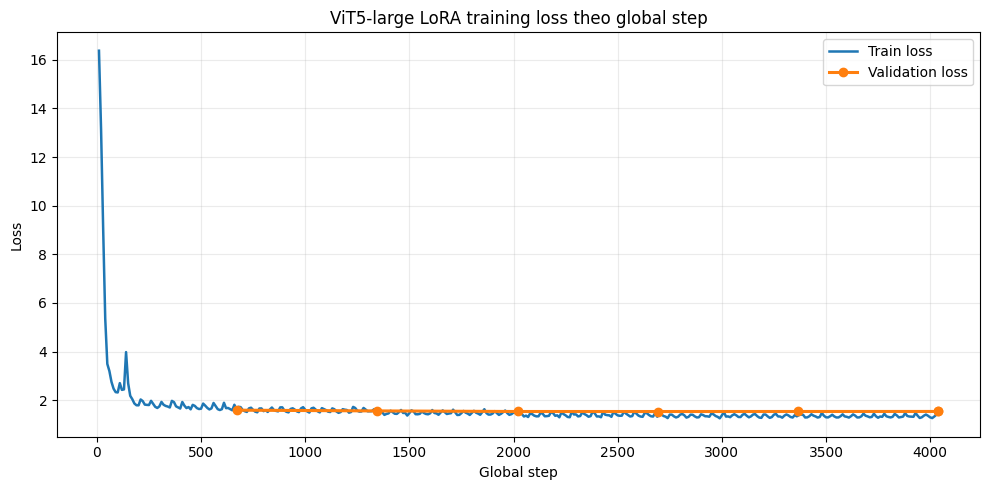

Epoch,Training Loss,Validation Loss
0,1.615400,1.591797
2,1.396100,1.537454
4,1.339400,1.537898
5,1.402700,1.539254


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Peak CUDA memory allocated: 38.55 GB
Peak CUDA memory reserved: 38.97 GB


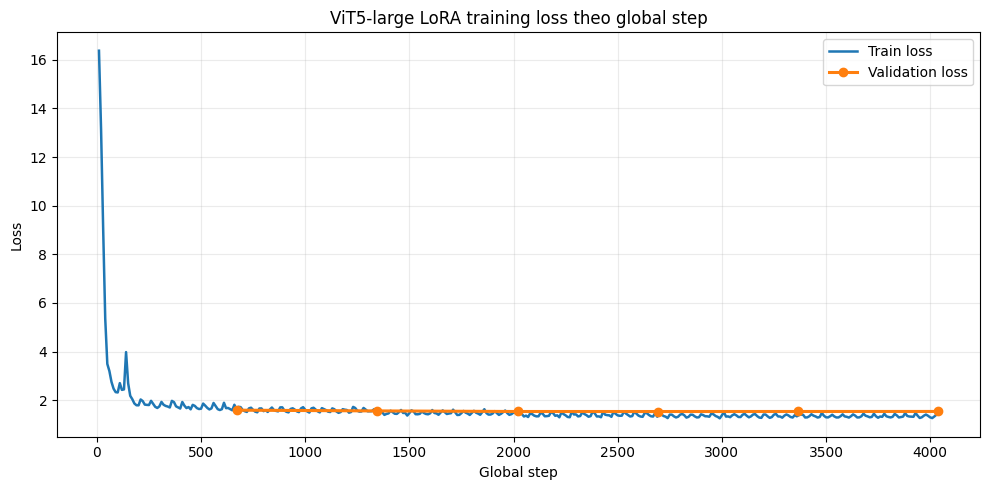

/tmp/ipykernel_2262/3187663783.py:289: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  loss_history_df = pd.concat([train_loss_df, eval_loss_df], ignore_index=True)


Saved step-level loss history to: /content/NLP/output/vit5_large_a100_40gb_loss_history.csv
Saved step-level loss plot to: /content/NLP/output/vit5_large_a100_40gb_loss_curve.png


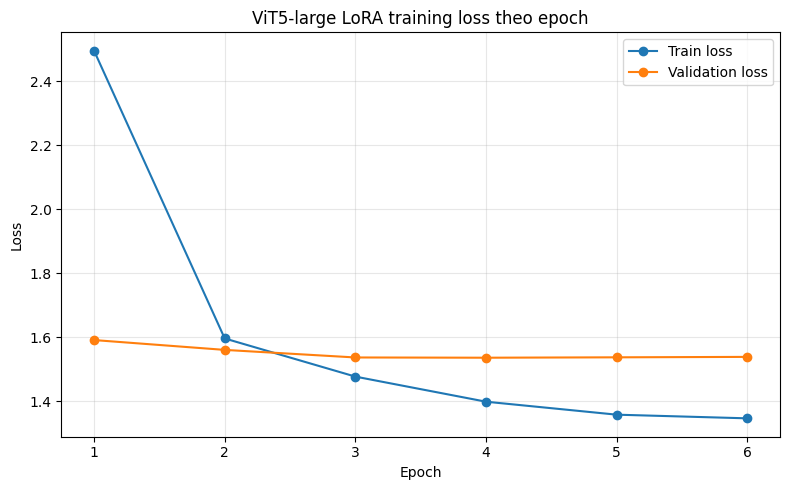

Saved epoch-level loss history to: /content/NLP/output/vit5_large_a100_40gb_epoch_loss_history.csv
Saved epoch-level loss plot to: /content/NLP/output/vit5_large_a100_40gb_epoch_loss_curve.png


,epoch,train_loss,valid_loss,learning_rate
0,1,2.495090,1.591797,9.690867e-05
1,2,1.596756,1.561101,8.043397e-05
2,3,1.477699,1.537454,5.497937e-05
3,4,1.399351,1.536686,2.803185e-05
4,5,1.358853,1.537898,7.452015e-06
5,6,1.347412,1.539254,1.096465e-09


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Saved model/adapters to: /content/NLP/output/vit5-large-lora-a100-40gb-balanced
Files in output: ['tokenizer_config.json', 'adapter_model.safetensors', 'special_tokens_map.json', 'README.md', 'checkpoint-4038', 'training_args.bin', 'spiece.model', 'added_tokens.json', 'adapter_config.json', 'checkpoint-3367', 'checkpoint-2694']


TrainOutput(global_step=4038, training_loss=1.6119096091385228, metrics={'train_runtime': 4927.3879, 'train_samples_per_second': 13.121, 'train_steps_per_second': 0.82, 'total_flos': 1.750592990831616e+17, 'train_loss': 1.6119096091385228, 'epoch': 6.0})

In [ ]:
# NHIỆM VỤ:
# - Tạo Trainer.
# - Train model.
# - Vẽ training loss/eval loss trong quá trình huấn luyện.
# - Lưu LoRA adapter, tokenizer, loss plot và loss history.
# - Xuất thêm biểu đồ train/validation loss theo epoch như notebook Transformer 2017.
# - In thông tin bộ nhớ để kiểm tra A100 40GB có được tận dụng tốt không.

def extract_loss_history(log_history):
    """Tách training loss và eval loss từ Trainer log_history thành 2 DataFrame.

    Trainer lưu log theo dạng list dictionary. Mỗi record có thể chứa:
    - loss: training loss tại một logging step.
    - eval_loss: validation loss tại một evaluation step.
    """

    train_rows = []
    eval_rows = []

    for record in log_history:
        step = record.get("step")
        epoch = record.get("epoch")

        if "loss" in record:
            train_rows.append({
                "type": "train",
                "step": step,
                "epoch": epoch,
                "loss": record["loss"],
                "learning_rate": record.get("learning_rate"),
            })

        if "eval_loss" in record:
            eval_rows.append({
                "type": "eval",
                "step": step,
                "epoch": epoch,
                "loss": record["eval_loss"],
                "learning_rate": record.get("learning_rate"),
            })

    train_df = pd.DataFrame(train_rows)
    eval_df = pd.DataFrame(eval_rows)
    return train_df, eval_df


def plot_loss_history(log_history, save_path=None, show=True):
    """Vẽ loss theo global step.

    Biểu đồ này chi tiết hơn biểu đồ theo epoch vì nó giữ toàn bộ log train loss.
    Eval loss thường chỉ có một vài điểm do evaluation chạy theo epoch.
    """

    train_df, eval_df = extract_loss_history(log_history)

    if train_df.empty and eval_df.empty:
        print("Chưa có loss để vẽ.")
        return train_df, eval_df

    fig, ax = plt.subplots(figsize=(10, 5))

    if not train_df.empty:
        ax.plot(
            train_df["step"],
            train_df["loss"],
            label="Train loss",
            linewidth=1.8,
        )

    if not eval_df.empty:
        ax.plot(
            eval_df["step"],
            eval_df["loss"],
            label="Validation loss",
            marker="o",
            linewidth=2.2,
        )

    ax.set_title("ViT5-large LoRA training loss theo global step")
    ax.set_xlabel("Global step")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.25)
    ax.legend()
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=160, bbox_inches="tight")

    if show:
        display(fig)

    plt.close(fig)
    return train_df, eval_df


def build_epoch_loss_summary(log_history):
    """Gom log của Trainer thành bảng train/validation loss theo epoch.

    Cách làm tương tự notebook Transformer 2017:
    - train_loss: trung bình các train loss log trong cùng epoch.
    - valid_loss: eval_loss được log ở cuối epoch.
    """

    train_df, eval_df = extract_loss_history(log_history)

    if train_df.empty and eval_df.empty:
        return pd.DataFrame(columns=["epoch", "train_loss", "valid_loss", "learning_rate"])

    rows = []

    if not train_df.empty:
        train_tmp = train_df.copy()
        train_tmp["epoch"] = pd.to_numeric(train_tmp["epoch"], errors="coerce")
        train_tmp = train_tmp.dropna(subset=["epoch"])

        # Epoch trong Trainer thường là số thực, ví dụ 0.125, 0.250, ..., 1.0.
        # Dùng ceil để các log trong khoảng (0, 1] thuộc epoch 1, (1, 2] thuộc epoch 2.
        train_tmp["epoch_index"] = np.ceil(train_tmp["epoch"]).astype(int)
        train_group = (
            train_tmp
            .groupby("epoch_index", as_index=False)
            .agg(
                train_loss=("loss", "mean"),
                learning_rate=("learning_rate", "last"),
            )
        )
    else:
        train_group = pd.DataFrame(columns=["epoch_index", "train_loss", "learning_rate"])

    if not eval_df.empty:
        eval_tmp = eval_df.copy()
        eval_tmp["epoch"] = pd.to_numeric(eval_tmp["epoch"], errors="coerce")
        eval_tmp = eval_tmp.dropna(subset=["epoch"])
        eval_tmp["epoch_index"] = np.rint(eval_tmp["epoch"]).astype(int)
        eval_group = (
            eval_tmp
            .groupby("epoch_index", as_index=False)
            .agg(valid_loss=("loss", "last"))
        )
    else:
        eval_group = pd.DataFrame(columns=["epoch_index", "valid_loss"])

    epoch_df = pd.merge(train_group, eval_group, on="epoch_index", how="outer")
    epoch_df = epoch_df.sort_values("epoch_index").reset_index(drop=True)
    epoch_df = epoch_df.rename(columns={"epoch_index": "epoch"})

    # Đảm bảo thứ tự cột dễ đọc.
    for col in ["train_loss", "valid_loss", "learning_rate"]:
        if col not in epoch_df.columns:
            epoch_df[col] = np.nan

    return epoch_df[["epoch", "train_loss", "valid_loss", "learning_rate"]]


def plot_epoch_loss_curve(epoch_loss_df, save_path=None, show=True):
    """Vẽ biểu đồ train loss và validation loss theo epoch.

    Đây là phiên bản gọn để đưa vào báo cáo, áp dụng cách vẽ của notebook
    transformer_2017_L4_22GB_improved_trained.ipynb sang ViT5.
    """

    if epoch_loss_df.empty:
        print("Chưa có epoch loss để vẽ.")
        return

    fig, ax = plt.subplots(figsize=(8, 5))

    if "train_loss" in epoch_loss_df and not epoch_loss_df["train_loss"].isna().all():
        ax.plot(
            epoch_loss_df["epoch"],
            epoch_loss_df["train_loss"],
            marker="o",
            label="Train loss",
        )

    if "valid_loss" in epoch_loss_df and not epoch_loss_df["valid_loss"].isna().all():
        ax.plot(
            epoch_loss_df["epoch"],
            epoch_loss_df["valid_loss"],
            marker="o",
            label="Validation loss",
        )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title("ViT5-large LoRA training loss theo epoch")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")

    if show:
        display(fig)

    plt.close(fig)


class LiveLossPlotCallback(TrainerCallback):
    """Callback cập nhật biểu đồ loss live mỗi khi Trainer ghi log."""

    def __init__(self, save_path=None, update_every_log=1):
        self.save_path = save_path
        self.update_every_log = max(1, int(update_every_log))
        self.log_count = 0

    def on_log(self, args, state, control, logs=None, **kwargs):
        logs = logs or {}
        if not LIVE_LOSS_PLOT:
            return
        if "loss" not in logs and "eval_loss" not in logs:
            return

        self.log_count += 1
        if self.log_count % self.update_every_log != 0:
            return

        # state.log_history đôi khi chưa có record hiện tại tại thời điểm callback chạy.
        current_record = dict(logs)
        current_record.setdefault("step", state.global_step)
        current_record.setdefault("epoch", state.epoch)
        history_for_plot = list(state.log_history) + [current_record]

        try:
            clear_output(wait=True)
            print("===== TRAIN CONFIG SUMMARY =====")
            print("global_step:", state.global_step, "| epoch:", state.epoch)
            if "loss" in logs:
                print("latest train loss:", logs["loss"])
            if "eval_loss" in logs:
                print("latest eval loss:", logs["eval_loss"])
            plot_loss_history(history_for_plot, save_path=self.save_path, show=True)
        except Exception as exc:
            print("Không thể cập nhật loss plot live:", exc)


loss_plot_callback = LiveLossPlotCallback(
    save_path=LOSS_PLOT_PNG,
    update_every_log=LOSS_PLOT_UPDATE_EVERY_LOG,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_valid,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics if PREDICT_WITH_GENERATE_DURING_TRAINING else None,
    callbacks=[loss_plot_callback],
)

print("===== TRAIN CONFIG SUMMARY =====")
print("per_device_train_batch_size:", training_args.per_device_train_batch_size)
print("gradient_accumulation_steps:", training_args.gradient_accumulation_steps)
print("effective_train_batch_size:", training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps)
print("bf16:", getattr(training_args, "bf16", None), "| fp16:", getattr(training_args, "fp16", None), "| tf32:", getattr(training_args, "tf32", None))
print("gradient_checkpointing:", training_args.gradient_checkpointing)
print("optim:", getattr(training_args, "optim", None))
print("lr_scheduler_type:", getattr(training_args, "lr_scheduler_type", None))
print("group_by_length:", getattr(training_args, "group_by_length", None))
print("dataloader_num_workers:", getattr(training_args, "dataloader_num_workers", None))
print("logging_steps:", training_args.logging_steps)
print("loss_plot_png:", LOSS_PLOT_PNG)
print("epoch_loss_plot_png:", LOSS_EPOCH_PLOT_PNG)

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

# Chạy fine-tune.
train_result = trainer.train()

if torch.cuda.is_available():
    peak_mem_gb = torch.cuda.max_memory_allocated() / 1024**3
    reserved_mem_gb = torch.cuda.max_memory_reserved() / 1024**3
    print(f"Peak CUDA memory allocated: {peak_mem_gb:.2f} GB")
    print(f"Peak CUDA memory reserved: {reserved_mem_gb:.2f} GB")

# Vẽ và lưu biểu đồ loss cuối cùng bằng toàn bộ log_history theo global step.
train_loss_df, eval_loss_df = plot_loss_history(
    trainer.state.log_history,
    save_path=LOSS_PLOT_PNG,
    show=True,
)

# Lưu lịch sử loss chi tiết theo step.
loss_history_df = pd.concat([train_loss_df, eval_loss_df], ignore_index=True)
if not loss_history_df.empty:
    loss_history_df.to_csv(LOSS_HISTORY_CSV, index=False)
    print("Saved step-level loss history to:", LOSS_HISTORY_CSV)
print("Saved step-level loss plot to:", LOSS_PLOT_PNG)

# Tạo bảng và biểu đồ loss theo epoch để đưa vào báo cáo.
epoch_loss_df = build_epoch_loss_summary(trainer.state.log_history)
if not epoch_loss_df.empty:
    epoch_loss_df.to_csv(LOSS_EPOCH_HISTORY_CSV, index=False)
    plot_epoch_loss_curve(
        epoch_loss_df,
        save_path=LOSS_EPOCH_PLOT_PNG,
        show=True,
    )
    print("Saved epoch-level loss history to:", LOSS_EPOCH_HISTORY_CSV)
    print("Saved epoch-level loss plot to:", LOSS_EPOCH_PLOT_PNG)
    display(epoch_loss_df)

# Lưu LoRA adapter/checkpoint tốt nhất theo eval_loss nếu load_best_model_at_end=True.
trainer.save_model(OUTPUT_DIR)

# Lưu tokenizer để sau này load lại đúng tokenizer.
tokenizer.save_pretrained(OUTPUT_DIR)

print("Saved model/adapters to:", OUTPUT_DIR)
print("Files in output:", os.listdir(OUTPUT_DIR))

train_result


## Cell 12 — Hàm generate summary theo batch

**Nhiệm vụ:** Định nghĩa hàm sinh tóm tắt cho một danh sách article.

**Ý nghĩa:** Dùng chung cho validation, demo thủ công và sau này có thể dùng cho test set.

In [ ]:
# NHIỆM VỤ:
# - Tạo hàm generate theo batch để inference nhanh hơn generate từng dòng.

def get_model_device(model):
    """Lấy device hiện tại của model.

    Parameters:
    - model:
        Model PyTorch hoặc PEFT model.

    Returns:
    - torch.device:
        Device của tham số đầu tiên trong model.
    """

    return next(model.parameters()).device


def generate_summaries(texts, batch_size=FINAL_GENERATE_BATCH_SIZE):
    """Sinh summary cho danh sách article.

    Parameters:
    - texts:
        List string chứa các article cần tóm tắt.
    - batch_size:
        Số article generate cùng lúc.
        Tăng batch_size giúp nhanh hơn nhưng tốn VRAM hơn.

    Returns:
    - List string chứa summary model sinh ra.
    """

    # Chuyển model sang eval để tắt dropout.
    model.eval()

    # Đưa model lên GPU nếu có.
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    predictions = []

    # Duyệt từng batch.
    for start_idx in range(0, len(texts), batch_size):
        batch_texts = texts[start_idx:start_idx + batch_size]

        # Thêm prefix nhiệm vụ và clean text.
        batch_inputs = [TASK_PREFIX + clean_text(text) for text in batch_texts]

        # Tokenize batch input.
        inputs = tokenizer(
            batch_inputs,
            max_length=MAX_SOURCE_LENGTH,
            # max_length:
            #   Giới hạn article đầu vào sau tokenize.

            truncation=True,
            # truncation:
            #   Cắt article nếu quá dài.

            padding=True,
            # padding:
            #   Padding các sample trong cùng batch về cùng độ dài.

            return_tensors="pt",
            # return_tensors:
            #   Trả tensor PyTorch.
        )

        # Đưa tensor lên cùng device với model.
        inputs = {k: v.to(device) for k, v in inputs.items()}

        # Inference không cần gradient.
        with torch.no_grad():
            output_ids = model.generate(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"],

                max_length=MAX_TARGET_LENGTH,
                # max_length:
                #   Độ dài tối đa của summary sinh ra.

                min_length=FINAL_MIN_LENGTH,
                # min_length:
                #   Độ dài tối thiểu để tránh summary quá ngắn.

                num_beams=FINAL_NUM_BEAMS,
                # num_beams:
                #   Số beam search. 4 thường cho chất lượng tốt hơn greedy.

                length_penalty=1.0,
                # length_penalty:
                #   1.0 là mặc định, không ưu tiên output quá ngắn/quá dài.

                no_repeat_ngram_size=FINAL_NO_REPEAT_NGRAM_SIZE,
                # no_repeat_ngram_size:
                #   Không cho lặp lại cụm n-gram, giảm repetition.

                early_stopping=True,
                # early_stopping:
                #   Dừng beam search khi các beam đã hoàn tất.
            )

        # Decode token IDs thành text.
        batch_predictions = tokenizer.batch_decode(
            output_ids,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=True,
        )

        predictions.extend([pred.strip() for pred in batch_predictions])

    return predictions

## Cell 13 — Sinh thử vài mẫu validation

**Nhiệm vụ:** In một vài article, summary chuẩn và summary model sinh.

**Ý nghĩa:** Đây là kiểm tra định tính nhanh sau training.

In [ ]:
# NHIỆM VỤ:
# - Sinh thử tối đa 3 mẫu validation để nhìn chất lượng ban đầu.

NUM_QUICK_EXAMPLES = min(3, len(valid_df))

quick_articles = valid_df[SOURCE_COL].head(NUM_QUICK_EXAMPLES).tolist()
quick_references = valid_df[TARGET_COL].head(NUM_QUICK_EXAMPLES).tolist()
quick_predictions = generate_summaries(
    quick_articles,
    batch_size=min(FINAL_GENERATE_BATCH_SIZE, NUM_QUICK_EXAMPLES),
)

for i, (article, reference, prediction) in enumerate(
    zip(quick_articles, quick_references, quick_predictions),
    start=1,
):
    print("=" * 100)
    print(f"EXAMPLE {i}")
    print("\nARTICLE:")
    print(article[:800], "...")
    print("\nREFERENCE SUMMARY:")
    print(reference)
    print("\nMODEL PREDICTION:")
    print(prediction)

EXAMPLE 1

ARTICLE:
Giải thưởng công bố gần đây bởi World Travel Awards. Đây là năm thứ hai liên tiếp InterContinental Phu Quoc Long Beach Resort được vinh danh ở hạng mục gia đình trên toàn châu Á. Khu nghỉ dưỡng tọa lạc bên biển Phú Quốc, nổi bật với thiết kế lấy cảm hứng từ đại dương. Khuôn viên rộng rãi với nhiều mảng xanh thiên nhiên đậm chất nhiệt đới. Không gian sảnh lễ tân, phòng nghỉ, villa, nhà hàng... đều được chú trọng để tạo sự hài hòa với biển và cây cối. Du khách có thể chọn nghỉ ngơi tại khu phòng khách sạn rộng rãi, tiện nghi, hoặc những căn hộ, phòng suite, biệt thự cao cấp hướng biển. Mỗi không gian được thiết kế dựa trên tinh thần gắn kết các thành viên trong gia đình. Bên cạnh tiện nghi sang trọng, InterContinental Phu Quoc còn hút khách gia đình nhờ loạt trải nghiệm giải trí, thư giãn đa ...

REFERENCE SUMMARY:
InterContinental Phu Quoc Long Beach Resort đã được vinh danh là khu nghỉ dưỡng gia đình tốt nhất châu Á lần thứ 2 liên tiếp. Khu nghỉ dưỡng này tọa lạc bê

## Cell 14 — Generate prediction trên validation set

**Nhiệm vụ:** Sinh prediction cho validation set hoặc một phần validation set rồi lưu CSV.

**Ý nghĩa:** File này dùng để tính ROUGE/BLEU và phân tích lỗi trong báo cáo.

In [ ]:
# NHIỆM VỤ:
# - Generate prediction trên validation.
# - Lưu article, reference, prediction ra CSV.

from tqdm.auto import tqdm  # Thanh tiến trình.

# Quyết định số mẫu validation dùng để generate.
# Nếu VALIDATION_MAX_GENERATE_SAMPLES=None:
#   - DEBUG_MODE=True: lấy tối đa 50 mẫu để chạy nhanh.
#   - DEBUG_MODE=False: generate toàn bộ validation.
if VALIDATION_MAX_GENERATE_SAMPLES is None:
    max_generate_samples = min(50, len(valid_df)) if DEBUG_MODE else len(valid_df)
else:
    max_generate_samples = min(VALIDATION_MAX_GENERATE_SAMPLES, len(valid_df))

# Lấy validation subset.
gen_df = valid_df.iloc[:max_generate_samples].copy().reset_index(drop=True)

print("Validation samples for generation:", len(gen_df))

# Lấy article/reference.
validation_articles = gen_df[SOURCE_COL].tolist()
validation_references = gen_df[TARGET_COL].tolist()

# Generate theo batch.
validation_predictions = []
for start_idx in tqdm(range(0, len(validation_articles), FINAL_GENERATE_BATCH_SIZE)):
    batch_articles = validation_articles[start_idx:start_idx + FINAL_GENERATE_BATCH_SIZE]
    batch_predictions = generate_summaries(
        batch_articles,
        batch_size=FINAL_GENERATE_BATCH_SIZE,
    )
    validation_predictions.extend(batch_predictions)

# Tạo DataFrame kết quả.
pred_df = pd.DataFrame({
    "article": validation_articles,
    "reference": validation_references,
    "prediction": validation_predictions,
})

# Lưu CSV.
# encoding="utf-8-sig": mở bằng Excel ít lỗi tiếng Việt hơn.
pred_df.to_csv(PREDICTION_CSV, index=False, encoding="utf-8-sig")

print("Saved validation predictions to:", PREDICTION_CSV)
display(pred_df.head())

Validation samples for generation: 1349


  0%|          | 0/85 [00:00<?, ?it/s]

Saved validation predictions to: /content/NLP/output/vit5_large_a100_40gb_validation_predictions.csv


,article,reference,prediction
0,Giải thưởng công bố gần đây bởi World Travel A...,InterContinental Phu Quoc Long Beach Resort đã...,"Một khu nghỉ dưỡng sang trọng tại Phú Quốc, In..."
1,Theo bảng xếp hạng 20 quốc gia tốt nhất thế gi...,Việt Nam đã xếp hạng 15 trên bảng xếp hạng 20 ...,"Ngày 10/10, tạp chí du lịch Mỹ Condé Nast Trav..."
2,"Ngày hội Văn hóa, Thể thao và Du lịch các dân ...","Ngày hội Văn hóa, Thể thao và Du lịch các dân ...","Ngày hội Văn hóa, Thể thao và Du lịch các dân ..."
3,Giải thưởng do Tạp chí du lịch Condé Nast Trav...,"Phú Quốc, đảo ngọc của Việt Nam, đã được vinh ...","Ngày 10/10, Việt Nam được vinh danh tại hai hạ..."
4,KKday Vietnam vừa công bố hợp tác chiến lược S...,KKday Vietnam vừa công bố hợp tác chiến lược v...,"Ngày 18/10, KKday Vietnam và Swiss Travel Syst..."


## Cell 15 — Tính ROUGE, BERTScore, BLEU và Too Short Rate trên validation

**Nhiệm vụ:** Tính các độ đo đánh giá tóm tắt giống notebook Transformer 2017:

- **ROUGE**: đo mức độ trùng n-gram/chuỗi con với summary chuẩn.
- **BERTScore**: đo mức gần nghĩa bằng embedding, chạy khi `RUN_BERTSCORE=True`.
- **BLEU**: metric n-gram tham khảo.
- **Too Short Rate**: tỷ lệ summary sinh ra quá ngắn so với ngưỡng hoặc so với reference.

**Ý nghĩa:** ROUGE/BLEU/BERTScore cho biết chất lượng so với reference; Too Short Rate giúp phát hiện model sinh output rỗng/quá cụt.


In [ ]:
# NHIỆM VỤ:
# - Tính ROUGE, BERTScore, BLEU và Too Short Rate trên validation prediction.
# - Lưu toàn bộ metric vào một file JSON để so sánh với model gốc hoặc model Transformer 2017.

from sacrebleu import corpus_bleu
from bert_score import score as bert_score


def metric_tokenize(text):
    """Tokenize đơn giản cho metric độ dài.

    Dùng split theo khoảng trắng để đo số token ở mức từ/cụm từ đã cách nhau bởi whitespace.
    Hàm này không dùng cho ROUGE/BLEU, chỉ dùng cho length-based metrics.
    """
    return str(text).strip().split()


def compute_rouge_scores(predictions, references):
    """Tính ROUGE bằng evaluate.

    use_stemmer=False vì stemmer của rouge-score chủ yếu dành cho tiếng Anh,
    không phù hợp để stemming tiếng Việt.
    """
    if len(predictions) == 0:
        return {
            "rouge1": 0.0,
            "rouge2": 0.0,
            "rougeL": 0.0,
            "rougeLsum": 0.0,
        }

    result = rouge.compute(
        predictions=predictions,
        references=references,
        use_stemmer=False,
    )

    return {key: float(value) for key, value in result.items()}


def compute_bleu_score(predictions, references):
    """Tính corpus BLEU bằng sacreBLEU.

    BLEU không phải metric chính cho summarization, nhưng có ích để tham khảo
    mức trùng n-gram giữa prediction và reference.
    """
    if len(predictions) == 0:
        return {"bleu": 0.0}

    bleu = corpus_bleu(
        predictions,
        [references],
        tokenize="intl",
    )

    return {"bleu": float(bleu.score)}


def compute_bertscore_scores(predictions, references):
    """Tính BERTScore Precision/Recall/F1 trung bình.

    BERTScore bổ sung góc nhìn ngữ nghĩa cho ROUGE/BLEU vì nó so sánh embedding
    thay vì chỉ so trùng token bề mặt.
    """
    if len(predictions) == 0:
        return {
            "bertscore_precision": 0.0,
            "bertscore_recall": 0.0,
            "bertscore_f1": 0.0,
        }

    bert_device = "cuda" if torch.cuda.is_available() else "cpu"

    precision, recall, f1 = bert_score(
        cands=predictions,
        refs=references,
        model_type=BERTSCORE_MODEL_TYPE,
        device=bert_device,
        batch_size=METRIC_BATCH_SIZE,
        verbose=True,
        rescale_with_baseline=False,
    )

    return {
        "bertscore_precision": float(precision.mean().item()),
        "bertscore_recall": float(recall.mean().item()),
        "bertscore_f1": float(f1.mean().item()),
    }


def compute_too_short_rate(predictions, references):
    """Tính tỷ lệ summary sinh ra quá ngắn.

    Một prediction được xem là quá ngắn nếu thỏa ít nhất một trong hai điều kiện:
    1. Số token prediction < TOO_SHORT_MIN_TOKENS.
    2. Số token prediction < TOO_SHORT_REF_RATIO * số token reference.

    Metric này đặc biệt hữu ích để phát hiện model sinh chuỗi rỗng, quá cụt,
    hoặc chỉ sinh vài từ nhưng ROUGE/BLEU không nói rõ nguyên nhân lỗi.
    """
    if len(predictions) == 0:
        return {
            "avg_prediction_tokens": 0.0,
            "avg_reference_tokens": 0.0,
            "avg_length_ratio_pred_ref": 0.0,
            "empty_prediction_rate": 0.0,
            "too_short_rate": 0.0,
            "too_short_min_tokens": TOO_SHORT_MIN_TOKENS,
            "too_short_ref_ratio": TOO_SHORT_REF_RATIO,
        }

    pred_lengths = [len(metric_tokenize(pred)) for pred in predictions]
    ref_lengths = [len(metric_tokenize(ref)) for ref in references]

    empty_flags = [length == 0 for length in pred_lengths]
    too_short_flags = []
    length_ratios = []

    for pred_len, ref_len in zip(pred_lengths, ref_lengths):
        safe_ref_len = max(1, ref_len)
        length_ratio = pred_len / safe_ref_len
        length_ratios.append(length_ratio)

        is_too_short = (
            pred_len < TOO_SHORT_MIN_TOKENS
            or pred_len < TOO_SHORT_REF_RATIO * safe_ref_len
        )
        too_short_flags.append(is_too_short)

    n = len(predictions)
    return {
        "avg_prediction_tokens": float(sum(pred_lengths) / n),
        "avg_reference_tokens": float(sum(ref_lengths) / n),
        "avg_length_ratio_pred_ref": float(sum(length_ratios) / n),
        "empty_prediction_rate": float(sum(empty_flags) / n),
        "too_short_rate": float(sum(too_short_flags) / n),
        "too_short_min_tokens": TOO_SHORT_MIN_TOKENS,
        "too_short_ref_ratio": TOO_SHORT_REF_RATIO,
    }


# Chuẩn bị list prediction/reference.
predictions = pred_df["prediction"].fillna("").astype(str).tolist()
references = pred_df["reference"].fillna("").astype(str).tolist()

# Tính metric.
rouge_metrics = compute_rouge_scores(predictions, references)
bleu_metrics = compute_bleu_score(predictions, references)
length_metrics = compute_too_short_rate(predictions, references)

if RUN_BERTSCORE:
    bertscore_metrics = compute_bertscore_scores(predictions, references)
else:
    bertscore_metrics = {
        "bertscore_precision": None,
        "bertscore_recall": None,
        "bertscore_f1": None,
    }

# Gom metric phẳng để dễ đưa vào bảng so sánh.
validation_metrics = {
    "num_validation_samples": len(pred_df),
    "debug_mode": DEBUG_MODE,
    "model_name": MODEL_NAME,
    "fine_tuning_method": "LoRA",
    "output_dir": OUTPUT_DIR,
    "task_prefix": TASK_PREFIX,
    "max_source_length": MAX_SOURCE_LENGTH,
    "max_target_length": MAX_TARGET_LENGTH,
    "final_num_beams": FINAL_NUM_BEAMS,
    "final_min_length": FINAL_MIN_LENGTH,
    "final_no_repeat_ngram_size": FINAL_NO_REPEAT_NGRAM_SIZE,
    "run_bertscore": RUN_BERTSCORE,
    "bert_score_model": BERTSCORE_MODEL_TYPE if RUN_BERTSCORE else None,
    **rouge_metrics,
    **bertscore_metrics,
    **bleu_metrics,
    **length_metrics,
}

# In metric dễ đọc.
print("===== VALIDATION METRICS =====")
for key, value in validation_metrics.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

# Lưu JSON tổng hợp.
with open(METRICS_JSON, "w", encoding="utf-8") as f:
    json.dump(validation_metrics, f, ensure_ascii=False, indent=2)

print("\nSaved validation metrics to:", METRICS_JSON)

# Lưu riêng BERTScore để tương thích với các notebook cũ nếu cần.
if RUN_BERTSCORE:
    with open(BERTSCORE_JSON, "w", encoding="utf-8") as f:
        json.dump(bertscore_metrics, f, ensure_ascii=False, indent=2)
    print("Saved BERTScore to:", BERTSCORE_JSON)

# Tạo bảng metric để xem nhanh trong notebook.
metric_rows = []
for key, value in validation_metrics.items():
    if isinstance(value, (int, float)) and key not in {"debug_mode"}:
        metric_rows.append({"metric": key, "value": value})

validation_metric_df = pd.DataFrame(metric_rows)
display(validation_metric_df)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

  0%|          | 0/338 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/169 [00:00<?, ?it/s]

done in 8.53 seconds, 158.11 sentences/sec
===== VALIDATION METRICS =====
num_validation_samples: 1349
debug_mode: False
model_name: VietAI/vit5-large
fine_tuning_method: LoRA
output_dir: /content/NLP/output/vit5-large-lora-a100-40gb-balanced
task_prefix: vietnamese summary: 
max_source_length: 768
max_target_length: 192
final_num_beams: 4
final_min_length: 30
final_no_repeat_ngram_size: 3
run_bertscore: True
bert_score_model: bert-base-multilingual-cased
rouge1: 0.7442
rouge2: 0.4856
rougeL: 0.5034
rougeLsum: 0.5031
bertscore_precision: 0.7954
bertscore_recall: 0.8015
bertscore_f1: 0.7981
bleu: 35.2431
avg_prediction_tokens: 102.0934
avg_reference_tokens: 102.0682
avg_length_ratio_pred_ref: 1.0398
empty_prediction_rate: 0.0000
too_short_rate: 0.0037
too_short_min_tokens: 5
too_short_ref_ratio: 0.5000

Saved validation metrics to: /content/NLP/output/vit5_large_a100_40gb_validation_metrics.json
Saved BERTScore to: /content/NLP/output/vit5_large_a100_40gb_validation_bertscore.json


,metric,value
0,num_validation_samples,1349
1,max_source_length,768
2,max_target_length,192
3,final_num_beams,4
4,final_min_length,30
5,final_no_repeat_ngram_size,3
6,run_bertscore,True
7,rouge1,0.744159
8,rouge2,0.485589
9,rougeL,0.503365


## Cell 16 — Gợi ý đọc các metric validation

**Nhiệm vụ:** Giải thích nhanh ý nghĩa các độ đo vừa tính.

**Ý nghĩa:** Cell này giúp bạn đưa kết quả vào báo cáo hoặc slide mà không nhầm vai trò của từng metric.


In [ ]:
# NHIỆM VỤ:
# - In giải thích ngắn về cách đọc metric để dùng trong báo cáo.

print("""
Cách đọc metric validation:

1. ROUGE-1:
   - Đo mức trùng từ đơn giữa prediction và reference.
   - Cao hơn thường nghĩa là model giữ được nhiều từ khóa/ý chính hơn.

2. ROUGE-2:
   - Đo mức trùng cụm 2 từ liên tiếp.
   - Đây là chỉ số khó hơn ROUGE-1; tăng ROUGE-2 thường cho thấy câu tóm tắt bám diễn đạt tốt hơn.

3. ROUGE-L / ROUGE-Lsum:
   - Đo chuỗi con chung dài nhất, quan tâm đến thứ tự thông tin.
   - Phù hợp để đánh giá cấu trúc summary.

4. BERTScore:
   - So sánh gần nghĩa bằng embedding.
   - Hữu ích khi prediction diễn đạt khác reference nhưng vẫn cùng ý.

5. BLEU:
   - Đo trùng n-gram, thường dùng nhiều trong dịch máy.
   - Với summarization, nên xem là metric phụ.

6. Too Short Rate:
   - Tỷ lệ prediction quá ngắn.
   - Nếu chỉ số này cao, model có dấu hiệu sinh summary cụt/rỗng dù một số metric khác có thể không phản ánh rõ.
""")



Cách đọc metric validation:

1. ROUGE-1:
   - Đo mức trùng từ đơn giữa prediction và reference.
   - Cao hơn thường nghĩa là model giữ được nhiều từ khóa/ý chính hơn.

2. ROUGE-2:
   - Đo mức trùng cụm 2 từ liên tiếp.
   - Đây là chỉ số khó hơn ROUGE-1; tăng ROUGE-2 thường cho thấy câu tóm tắt bám diễn đạt tốt hơn.

3. ROUGE-L / ROUGE-Lsum:
   - Đo chuỗi con chung dài nhất, quan tâm đến thứ tự thông tin.
   - Phù hợp để đánh giá cấu trúc summary.

4. BERTScore:
   - So sánh gần nghĩa bằng embedding.
   - Hữu ích khi prediction diễn đạt khác reference nhưng vẫn cùng ý.

5. BLEU:
   - Đo trùng n-gram, thường dùng nhiều trong dịch máy.
   - Với summarization, nên xem là metric phụ.

6. Too Short Rate:
   - Tỷ lệ prediction quá ngắn.
   - Nếu chỉ số này cao, model có dấu hiệu sinh summary cụt/rỗng dù một số metric khác có thể không phản ánh rõ.



## Cell 17 — Lưu ví dụ định tính cho báo cáo

**Nhiệm vụ:** Lấy một số mẫu validation gồm article, summary chuẩn và prediction của model.

**Ý nghĩa:** Dùng cho phần qualitative evaluation/error analysis trong báo cáo.

In [ ]:
# NHIỆM VỤ:
# - Lấy ví dụ định tính từ pred_df.
# - Lưu ra CSV để đưa vào báo cáo.

# Số ví dụ muốn lấy.
# min(10, len(pred_df)): tránh lỗi nếu pred_df ít hơn 10 dòng.
NUM_EXAMPLES_FOR_REPORT = min(10, len(pred_df))

# sample(..., random_state=42): lấy mẫu ngẫu nhiên nhưng tái lập được.
examples_df = pred_df.sample(
    n=NUM_EXAMPLES_FOR_REPORT,
    random_state=42,
).copy()

# Lưu CSV.
examples_df.to_csv(EXAMPLES_CSV, index=False, encoding="utf-8-sig")

print("Saved examples to:", EXAMPLES_CSV)
display(examples_df)

Saved examples to: /content/NLP/output/vit5_large_a100_40gb_examples_for_report.csv


,article,reference,prediction
289,"TheoThe Paper, khán giả vốn quen Giả Linh với ...","Diễn viên Giả Linh, nổi tiếng với hình tượng m...","Tác phẩm ""Yolo"" của Giả Linh kể về quá trình t..."
1036,"Phút 43, trận đấu trên sân Sultan Ibrahim (ban...",Trong trận đấu giữa Buriram United (Thái Lan) ...,Trận đấu giữa Buriram United và JDT diễn ra qu...
535,Ngân hàng Trung ương Nga cuối tuần trước thông...,Ngân hàng Trung ương Nga vừa thông báo giá trị...,Ngân hàng Trung ương Nga vừa thông báo giá trị...
346,"Theo đại diện tuyển sinh các trường, đây là th...",Ngày 17/8 là thời điểm kết thúc việc xử lý ngu...,Bộ Giáo dục và Đào tạo đã kết thúc việc xử lý ...
1075,"""Có nhiều thứ của Liverpool khiến tôi nhớ đến ...",Gary Neville ca ngợi sự đa dạng chiến thuật củ...,Trận đấu giữa Liverpool và Tottenham kết thúc ...
782,Ngoài chính sách giảm 50% lệ phí trước bạ từ C...,Chính phủ đang áp dụng chính sách giảm 50% lệ ...,"Ngày 30/11, Chính phủ áp dụng ưu đãi 50% lệ ph..."
303,Con trai họa sĩ - ông Hồ Hồng Lĩnh - cho biết ...,Họa sĩ Hồ Hữu Thủ sinh năm 1940 tại Thủ Dầu Mộ...,"Họa sĩ Hồ Hữu Thủ, sinh năm 1940 tại Thủ Dầu M..."
754,Mẫu concept EV Fun chưa phải là phiên bản sản ...,Honda đã trình diễn hai mẫu xe điện tại triển ...,Honda EV Fun là mẫu xe thể thao điện tương đươ...
536,"Chốt phiên giao dịch 11/11, giá vàng thế giới ...","Sau khi ông Donald Trump đắc cử Tổng thống Mỹ,...",Giá vàng thế giới giảm hơn 64 USD xuống 2.619 ...
76,Khoảng 200 con khỉ hôm 16/11 lang thang trên đ...,Khoảng 200 con khỉ lang thang trên đường phố v...,"Ngày 16/11, khoảng 200 con khỉ đã lang thang t..."


## Các cell test set độc lập — Đã comment toàn bộ vì chưa có `test.parquet`

**Vị trí đặt:** Sau khi model đã train xong và đã có hàm `generate_summaries`.

**Cách dùng sau này:** Khi bạn có `/content/NLP/data/test.parquet`, bỏ dấu `#` ở các dòng trong các cell bên dưới rồi chạy từ trên xuống.

**Lưu ý quan trọng:** Validation dùng trong quá trình train/điều chỉnh; test set chỉ dùng một lần cuối để đánh giá khách quan.

### Cell Test 1 — Cấu hình và đọc `test.parquet`

In [ ]:
# # ============================================================
# # OPTIONAL TEST CELL 1: Cấu hình và đọc test.parquet
# # ============================================================
# # NHIỆM VỤ:
# # - Khai báo đường dẫn test set độc lập.
# # - Đọc test.parquet.
# # - Làm sạch giống train/validation.
# #
# # Vì hiện tại chưa có test.parquet nên toàn bộ cell này được comment.
# # Khi có file test, bỏ dấu # ở các dòng cần chạy.
#
# TEST_PATH = f"{DATA_DIR}/test.parquet"
# # TEST_PATH:
# #   Đường dẫn file test độc lập.
# #   File này nên có cùng schema với train/val: article và summary.
#
# TEST_OUTPUT_DIR = f"{OUTPUT_BASE_DIR}/test_evaluation"
# # TEST_OUTPUT_DIR:
# #   Thư mục lưu prediction/metric trên test set.
#
# TEST_PREDICTION_CSV = f"{TEST_OUTPUT_DIR}/test_predictions.csv"
# # TEST_PREDICTION_CSV:
# #   File CSV lưu article, reference, prediction trên test.
#
# TEST_METRICS_JSON = f"{TEST_OUTPUT_DIR}/test_metrics.json"
# # TEST_METRICS_JSON:
# #   File JSON lưu ROUGE/BLEU/BERTScore trên test.
#
# TEST_MAX_SAMPLES = None
# # TEST_MAX_SAMPLES:
# #   None nghĩa là đánh giá toàn bộ test set.
# #   Có thể đặt 100 hoặc 200 nếu muốn chạy thử nhanh.
#
# TEST_BATCH_SIZE = 4
# # TEST_BATCH_SIZE:
# #   Batch size khi generate trên test.
# #   Nếu T4 bị OOM, giảm xuống 2 hoặc 1.
#
# os.makedirs(TEST_OUTPUT_DIR, exist_ok=True)
#
# if not os.path.exists(TEST_PATH):
#     raise FileNotFoundError(f"Chưa tìm thấy test file: {TEST_PATH}")
#
# test_df = load_and_clean_parquet(TEST_PATH)
#
# if TEST_MAX_SAMPLES is not None:
#     test_df = test_df.head(TEST_MAX_SAMPLES).reset_index(drop=True)
#
# print("Test used:", test_df.shape)
# display(test_df.head())

### Cell Test 2 — Kiểm tra trùng lặp train/validation/test

In [ ]:
# # ============================================================
# # OPTIONAL TEST CELL 2: Kiểm tra data leakage
# # ============================================================
# # NHIỆM VỤ:
# # - Kiểm tra article trong test có trùng train hoặc validation không.
# # - Nếu trùng nhiều, metric test sẽ không còn khách quan.
#
# def normalize_for_leakage_check(text):
#     """Chuẩn hóa nhẹ text để so sánh trùng lặp."""
#     return " ".join(str(text).lower().strip().split())
#
# train_articles = set(train_df[SOURCE_COL].map(normalize_for_leakage_check))
# # train_articles:
# #   Tập article train đã normalize để kiểm tra trùng.
#
# valid_articles = set(valid_df[SOURCE_COL].map(normalize_for_leakage_check))
# # valid_articles:
# #   Tập article validation đã normalize.
#
# test_articles = set(test_df[SOURCE_COL].map(normalize_for_leakage_check))
# # test_articles:
# #   Tập article test đã normalize.
#
# overlap_train_test = len(train_articles.intersection(test_articles))
# # overlap_train_test:
# #   Số article test bị trùng train.
#
# overlap_valid_test = len(valid_articles.intersection(test_articles))
# # overlap_valid_test:
# #   Số article test bị trùng validation.
#
# print("Số article test trùng train:", overlap_train_test)
# print("Số article test trùng validation:", overlap_valid_test)
# print("Tỷ lệ trùng train-test:", overlap_train_test / max(len(test_articles), 1))
# print("Tỷ lệ trùng valid-test:", overlap_valid_test / max(len(test_articles), 1))

### Cell Test 3 — Generate prediction trên test set

In [ ]:
# # ============================================================
# # OPTIONAL TEST CELL 3: Generate prediction trên test set
# # ============================================================
# # NHIỆM VỤ:
# # - Dùng model fine-tuned để sinh summary cho test set.
# # - Không cập nhật trọng số model.
#
# test_articles = test_df[SOURCE_COL].tolist()
# # test_articles:
# #   Danh sách article test đầu vào.
#
# test_references = test_df[TARGET_COL].tolist()
# # test_references:
# #   Danh sách summary chuẩn của test.
#
# test_predictions = []
# # test_predictions:
# #   Nơi lưu summary do model sinh ra.
#
# for start_idx in tqdm(range(0, len(test_articles), TEST_BATCH_SIZE)):
#     batch_articles = test_articles[start_idx:start_idx + TEST_BATCH_SIZE]
#     # batch_articles:
#     #   Một batch article để generate.
#
#     batch_predictions = generate_summaries(
#         batch_articles,
#         batch_size=TEST_BATCH_SIZE,
#     )
#     # batch_predictions:
#     #   Summary sinh ra cho batch hiện tại.
#
#     test_predictions.extend(batch_predictions)
#
# test_pred_df = pd.DataFrame({
#     "article": test_articles,
#     "reference": test_references,
#     "prediction": test_predictions,
# })
#
# test_pred_df.to_csv(TEST_PREDICTION_CSV, index=False, encoding="utf-8-sig")
#
# print("Saved test predictions to:", TEST_PREDICTION_CSV)
# display(test_pred_df.head())

### Cell Test 4 — Tính ROUGE/BLEU/BERTScore trên test set

In [ ]:
# # ============================================================
# # OPTIONAL TEST CELL 4: Tính ROUGE/BERTScore/BLEU/Too Short Rate trên test
# # ============================================================
# # NHIỆM VỤ:
# # - Tính metric test giống validation.
# # - Chỉ chạy khi test.parquet có cột summary/reference.
# # - Nếu test.parquet không có summary, chỉ lưu prediction để nộp.
#
# test_predictions_list = test_pred_df["prediction"].fillna("").astype(str).tolist()
# # test_predictions_list:
# #   Danh sách summary model sinh ra.
#
# test_references_list = test_pred_df["reference"].fillna("").astype(str).tolist()
# # test_references_list:
# #   Danh sách summary chuẩn.
#
# test_rouge_metrics = compute_rouge_scores(
#     predictions=test_predictions_list,
#     references=test_references_list,
# )
# # test_rouge_metrics:
# #   ROUGE-1, ROUGE-2, ROUGE-L, ROUGE-Lsum trên test.
#
# test_bleu_metrics = compute_bleu_score(
#     predictions=test_predictions_list,
#     references=test_references_list,
# )
# # test_bleu_metrics:
# #   BLEU trên test, chỉ dùng tham khảo.
#
# test_length_metrics = compute_too_short_rate(
#     predictions=test_predictions_list,
#     references=test_references_list,
# )
# # test_length_metrics:
# #   Độ dài trung bình, tỷ lệ prediction rỗng và tỷ lệ prediction quá ngắn.
#
# RUN_TEST_BERTSCORE = RUN_BERTSCORE
# # RUN_TEST_BERTSCORE:
# #   True để tính BERTScore test.
# #   False để bỏ qua nếu muốn chạy nhanh.
#
# if RUN_TEST_BERTSCORE:
#     test_bertscore_metrics = compute_bertscore_scores(
#         predictions=test_predictions_list,
#         references=test_references_list,
#     )
# else:
#     test_bertscore_metrics = {
#         "bertscore_precision": None,
#         "bertscore_recall": None,
#         "bertscore_f1": None,
#     }
#
# test_metrics = {
#     "num_test_samples": len(test_pred_df),
#     "model_name": MODEL_NAME,
#     "fine_tuning_method": "LoRA",
#     "run_bertscore": RUN_TEST_BERTSCORE,
#     "bert_score_model": BERTSCORE_MODEL_TYPE if RUN_TEST_BERTSCORE else None,
#     **test_rouge_metrics,
#     **test_bertscore_metrics,
#     **test_bleu_metrics,
#     **test_length_metrics,
# }
#
# print("===== TEST METRICS =====")
# print(json.dumps(test_metrics, ensure_ascii=False, indent=2))
#
# with open(TEST_METRICS_JSON, "w", encoding="utf-8") as f:
#     json.dump(test_metrics, f, ensure_ascii=False, indent=2)
#
# print("Saved test metrics to:", TEST_METRICS_JSON)


### Cell Test 5 — Xem ví dụ định tính trên test set

In [ ]:
# # ============================================================
# # OPTIONAL TEST CELL 5: Xem ví dụ prediction trên test set
# # ============================================================
# # NHIỆM VỤ:
# # - Xem trực tiếp model tóm tắt như thế nào trên test.
# # - Giúp phát hiện lỗi copy nguyên văn, sai ý, thiếu ý chính hoặc lặp từ.
#
# NUM_TEST_EXAMPLES_TO_SHOW = 5
# # NUM_TEST_EXAMPLES_TO_SHOW:
# #   Số ví dụ test muốn in ra màn hình.
#
# for i in range(min(NUM_TEST_EXAMPLES_TO_SHOW, len(test_pred_df))):
#     print("=" * 100)
#     print(f"TEST EXAMPLE {i + 1}")
#
#     print("\nARTICLE:")
#     print(test_pred_df.loc[i, "article"][:1500])
#
#     print("\nREFERENCE SUMMARY:")
#     print(test_pred_df.loc[i, "reference"])
#
#     print("\nMODEL PREDICTION:")
#     print(test_pred_df.loc[i, "prediction"])

## Cell 18 — Demo với văn bản tự nhập

**Nhiệm vụ:** Nhập một article bất kỳ và xem model tóm tắt.

**Ý nghĩa:** Cell này dùng để demo nhanh, không ảnh hưởng metric chính.

In [ ]:
# NHIỆM VỤ:
# - Chạy thử model với một văn bản tự nhập.

# @title Chạy thử mô hình với văn bản của bạn

custom_article = "Redmi Note 12 Turbo là một trong những mẫu smartphone tầm trung nổi bật nhất của Xiaomi khi ra mắt vào tháng 3 năm 2023. Đây cũng là chiếc điện thoại đầu tiên trên thế giới được trang bị vi xử lý Snapdragon 7+ Gen 2, con chip mang lại hiệu năng mạnh mẽ và tiệm cận với nhiều thiết bị cao cấp trên thị trường. Nhờ được sản xuất trên tiến trình 4nm của TSMC, bộ xử lý này không chỉ cho khả năng vận hành mượt mà mà còn tối ưu điện năng hiệu quả. Người dùng có thể dễ dàng thực hiện các tác vụ hằng ngày như lướt web, xem phim, làm việc trực tuyến hay chơi những tựa game đồ họa nặng như PUBG Mobile, Call of Duty Mobile hoặc Genshin Impact với mức thiết lập cao mà vẫn duy trì được độ ổn định tốt. Bên cạnh hiệu năng mạnh mẽ, Redmi Note 12 Turbo còn được trang bị màn hình OLED kích thước 6,67 inch với độ phân giải Full HD+, tần số quét 120Hz cùng công nghệ HDR10+ và Dolby Vision. Nhờ đó, thiết bị mang đến chất lượng hiển thị sắc nét, màu sắc sống động và trải nghiệm vuốt chạm mượt mà trong mọi tác vụ. Độ sáng cao của màn hình cũng giúp người dùng dễ dàng sử dụng điện thoại trong điều kiện ánh sáng mạnh ngoài trời. Về khả năng chụp ảnh, Redmi Note 12 Turbo sở hữu cụm camera sau gồm cảm biến chính 64MP hỗ trợ chống rung quang học OIS, camera góc siêu rộng 8MP và camera macro 2MP. Hệ thống camera này cho phép chụp được những bức ảnh có độ chi tiết tốt, khả năng xử lý trong điều kiện thiếu sáng khá ổn và hỗ trợ quay video 4K. Ngoài ra, tính năng zoom 2x chất lượng cao cũng giúp người dùng linh hoạt hơn trong việc ghi lại các khoảnh khắc hằng ngày. Máy còn được trang bị viên pin dung lượng 5.000mAh kết hợp công nghệ sạc nhanh 67W, giúp đáp ứng tốt nhu cầu sử dụng liên tục trong cả ngày dài và rút ngắn đáng kể thời gian chờ sạc. Một điểm mạnh khác của Redmi Note 12 Turbo là bộ nhớ lớn với các tùy chọn lên đến 16GB RAM LPDDR5 và 1TB bộ nhớ trong UFS 3.1, mang lại khả năng đa nhiệm mượt mà và không gian lưu trữ rộng rãi cho hình ảnh, video, tài liệu hay các ứng dụng dung lượng lớn. Ngoài ra, hệ thống loa kép stereo hỗ trợ Dolby Atmos cùng jack cắm tai nghe 3.5mm cũng góp phần nâng cao trải nghiệm giải trí của người dùng. Tuy nhiên, dù sở hữu nhiều ưu điểm nổi bật, Redmi Note 12 Turbo không còn là lựa chọn thực sự hấp dẫn trong năm 2025. Nguyên nhân chính là thiết bị không được Xiaomi phân phối chính hãng tại Việt Nam mà chủ yếu xuất hiện dưới dạng hàng xách tay hoặc hàng nhập khẩu. Điều này khiến người dùng gặp nhiều hạn chế liên quan đến chế độ bảo hành, hỗ trợ kỹ thuật và cập nhật phần mềm. Trong trường hợp thiết bị gặp lỗi phần cứng hoặc cần sửa chữa, việc tìm kiếm linh kiện thay thế và nhận hỗ trợ cũng có thể gặp khó khăn hơn so với các sản phẩm chính hãng. Mặc dù mức giá của Redmi Note 12 Turbo hiện nay khá cạnh tranh, nhưng khi cân nhắc đến các yếu tố sử dụng lâu dài, đây không còn là sự lựa chọn tối ưu cho đa số người dùng. Thay vào đó, các mẫu Redmi Note thế hệ mới được phân phối chính hãng tại Việt Nam sẽ mang lại sự an tâm hơn nhờ được hỗ trợ phần mềm mới, chế độ bảo hành đầy đủ và nhiều cải tiến về công nghệ. Có thể nói rằng Redmi Note 12 Turbo từng là một trong những smartphone tầm trung đáng mua nhất khi ra mắt nhờ hiệu năng mạnh, màn hình đẹp, pin lớn và khả năng sạc nhanh." # @param {type:"string"}
# custom_article:
#   Văn bản đầu vào tự nhập.
# @param {type:"string"}:
#   Cú pháp Colab để hiện ô nhập string trên giao diện.

print("Đang tạo tóm tắt...")

custom_prediction = generate_summaries(
    [custom_article],
    batch_size=1,
)[0]

print("\n" + "=" * 80)
print("📝 BÀI VIẾT GỐC:")
print(custom_article)
print("-" * 80)
print("✨ TÓM TẮT CỦA MÔ HÌNH:")
print(custom_prediction)
print("=" * 80)

Đang tạo tóm tắt...

📝 BÀI VIẾT GỐC:
Redmi Note 12 Turbo là một trong những mẫu smartphone tầm trung nổi bật nhất của Xiaomi khi ra mắt vào tháng 3 năm 2023. Đây cũng là chiếc điện thoại đầu tiên trên thế giới được trang bị vi xử lý Snapdragon 7+ Gen 2, con chip mang lại hiệu năng mạnh mẽ và tiệm cận với nhiều thiết bị cao cấp trên thị trường. Nhờ được sản xuất trên tiến trình 4nm của TSMC, bộ xử lý này không chỉ cho khả năng vận hành mượt mà mà còn tối ưu điện năng hiệu quả. Người dùng có thể dễ dàng thực hiện các tác vụ hằng ngày như lướt web, xem phim, làm việc trực tuyến hay chơi những tựa game đồ họa nặng như PUBG Mobile, Call of Duty Mobile hoặc Genshin Impact với mức thiết lập cao mà vẫn duy trì được độ ổn định tốt. Bên cạnh hiệu năng mạnh mẽ, Redmi Note 12 Turbo còn được trang bị màn hình OLED kích thước 6,67 inch với độ phân giải Full HD+, tần số quét 120Hz cùng công nghệ HDR10+ và Dolby Vision. Nhờ đó, thiết bị mang đến chất lượng hiển thị sắc nét, màu sắc sống động và trải n

## Cell 19 — Nén output để tải về

**Nhiệm vụ:** Gom adapter, tokenizer, prediction CSV, metric JSON và ví dụ báo cáo vào một file `.zip`.

**Ý nghĩa:** Sau khi chạy xong trên Colab, tải file zip này để lưu local, nộp bài hoặc đưa lên GitHub.

In [ ]:
# NHIỆM VỤ:
# - Nén các file/thư mục output quan trọng.

import zipfile

# Chuyển đường dẫn sang Path object.
output_base = Path(OUTPUT_BASE_DIR)
zip_path = Path(ZIP_PATH)

# Danh sách item cần zip.
items_to_zip = [
    Path(OUTPUT_DIR),
    # OUTPUT_DIR:
    #   Thư mục chứa LoRA adapter và tokenizer.

    Path(PREDICTION_CSV),
    # PREDICTION_CSV:
    #   Prediction validation.

    Path(METRICS_JSON),
    # METRICS_JSON:
    #   ROUGE/BLEU validation.

    Path(BERTSCORE_JSON),
    # BERTSCORE_JSON:
    #   BERTScore validation nếu có.

    Path(EXAMPLES_CSV),
    # EXAMPLES_CSV:
    #   Ví dụ định tính cho báo cáo.

    Path(LOSS_PLOT_PNG),
    # LOSS_PLOT_PNG:
    #   Biểu đồ training loss/eval loss.

    Path(LOSS_HISTORY_CSV),
    # LOSS_HISTORY_CSV:
    #   Lịch sử loss chi tiết theo global step.

    Path(LOSS_EPOCH_PLOT_PNG),
    # LOSS_EPOCH_PLOT_PNG:
    #   Biểu đồ train loss/validation loss theo epoch.

    Path(LOSS_EPOCH_HISTORY_CSV),
    # LOSS_EPOCH_HISTORY_CSV:
    #   Bảng train loss/validation loss theo epoch để đưa vào báo cáo.

    Path(f"{OUTPUT_BASE_DIR}/test_evaluation"),
    # test_evaluation:
    #   Thư mục test nếu sau này bạn bỏ comment các cell test.
]

with zipfile.ZipFile(
    zip_path,
    "w",
    compression=zipfile.ZIP_DEFLATED,
    # compression:
    #   Nén file để giảm dung lượng tải về.
) as zf:
    for item in items_to_zip:
        # Bỏ qua item chưa tồn tại.
        if not item.exists():
            continue

        if item.is_dir():
            # Nếu là thư mục, zip toàn bộ file bên trong.
            for file_path in item.rglob("*"):
                if file_path.is_file() and file_path != zip_path:
                    zf.write(
                        file_path,
                        arcname=file_path.relative_to(output_base),
                        # arcname:
                        #   Đường dẫn tương đối bên trong file zip.
                    )
        else:
            # Nếu là file đơn lẻ, zip trực tiếp.
            zf.write(
                item,
                arcname=item.relative_to(output_base),
            )

print("Output zip:", zip_path)


Output zip: /content/NLP/output/vit5_large_a100_40gb_outputs.zip
